# V3 Data Exploration

Quick sanity checks on the V3 dataset:
- Correct local velocity (R.T @ global)
- integral_pos_err present
- 35-dim raw frames, 70 stacked
- Obstacle & APF effects visible in labels

In [1]:
import sys, torch, numpy as np, matplotlib.pyplot as plt
sys.path.insert(0, '../src')
from dataloader import SplitDataset

TRAIN = r"../datasets/setpoint_V3_mixed_formations_train.pt"
ds = SplitDataset(TRAIN)
print(f"Graphs: {len(ds)}")
s = ds[0]
print(f"x: {tuple(s.x.shape)}  target: {tuple(s.target.shape)}  edges: {tuple(s.edge_attr.shape)}")

c:\Users\aimen\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Graphs: 1600
x: (15, 70)  target: (15, 4)  edges: (88, 7)


## Feature Distributions

C:\Users\aimen\AppData\Local\Temp\ipykernel_16812\2692029942.py:1: UserWarning: It is not recommended to directly access the internal storage format `data` of an 'InMemoryDataset'. The data of the dataset is already cached, so any modifications to `data` will not be reflected when accessing its elements. Clearing the cache now by removing all elements in `dataset._data_list`. If you are absolutely certain what you are doing, access the internal storage via `InMemoryDataset._data` instead to suppress this warning. Alternatively, you can access stacked individual attributes of every graph via `dataset.{attr_name}`.
  all_x = ds.data.x


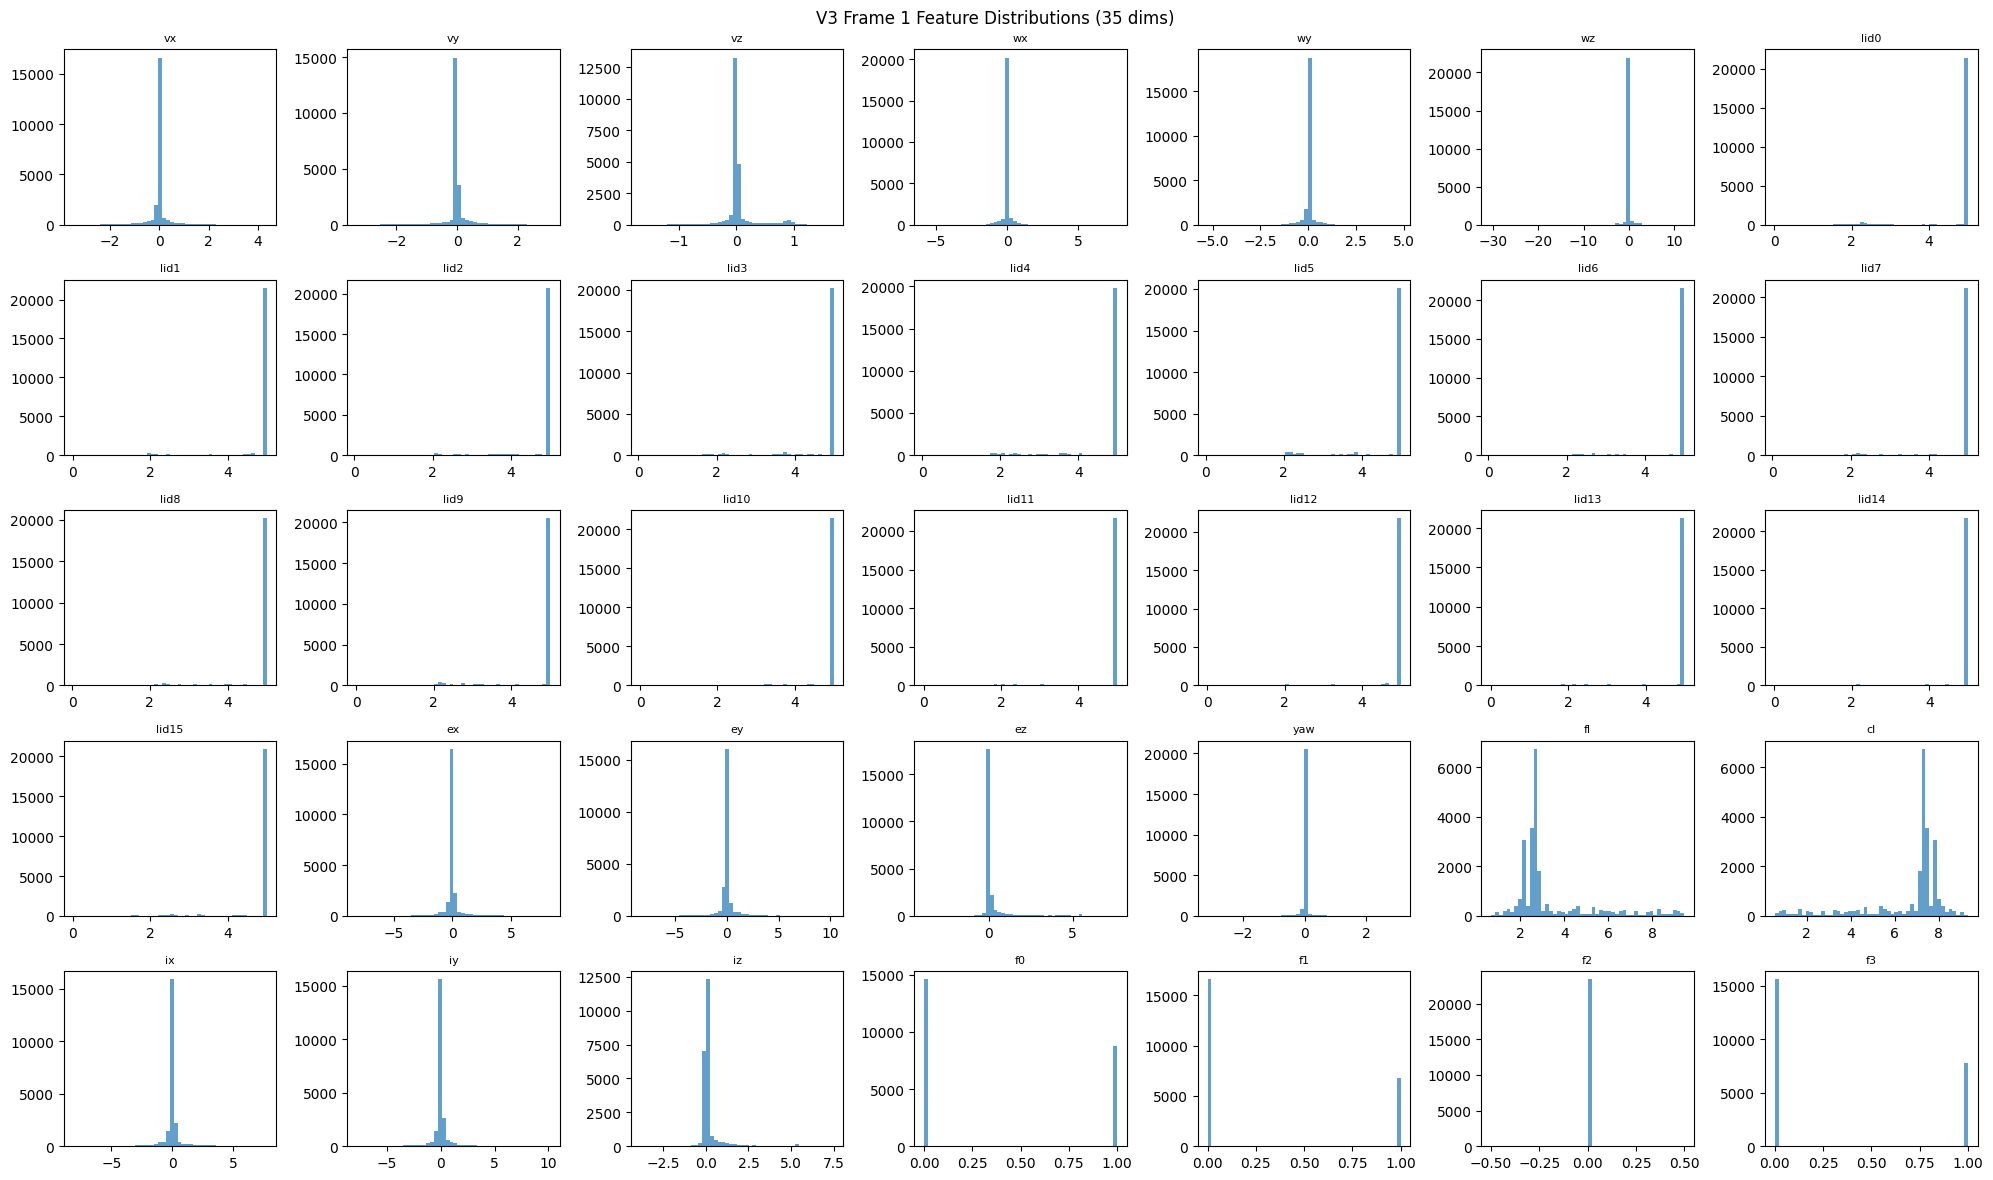

In [2]:
all_x = ds.data.x
labels = ['vx','vy','vz','wx','wy','wz'] + [f'lid{i}' for i in range(16)] + ['ex','ey','ez','yaw','fl','cl','ix','iy','iz'] + ['f0','f1','f2','f3']
fig, axes = plt.subplots(5, 7, figsize=(20, 12))
for i, ax in enumerate(axes.flat):
    if i >= 35: ax.axis('off'); continue
    ax.hist(all_x[:, i].numpy(), bins=50, alpha=0.7)
    ax.set_title(labels[i], fontsize=8)
plt.suptitle('V3 Frame 1 Feature Distributions (35 dims)')
plt.tight_layout()
plt.show()

## Label Distributions

C:\Users\aimen\AppData\Local\Temp\ipykernel_16812\1646829156.py:1: UserWarning: It is not recommended to directly access the internal storage format `data` of an 'InMemoryDataset'. If you are absolutely certain what you are doing, access the internal storage via `InMemoryDataset._data` instead to suppress this warning. Alternatively, you can access stacked individual attributes of every graph via `dataset.{attr_name}`.
  all_y = ds.data.target


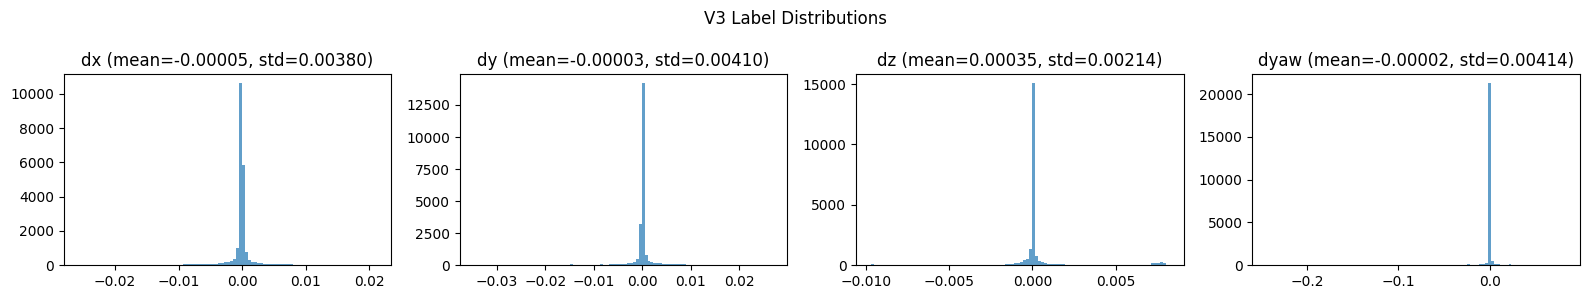

In [3]:
all_y = ds.data.target
fig, axes = plt.subplots(1, 4, figsize=(16, 3))
for i, (ax, name) in enumerate(zip(axes, ['dx','dy','dz','dyaw'])):
    ax.hist(all_y[:, i].numpy(), bins=100, alpha=0.7)
    ax.set_title(f'{name} (mean={all_y[:,i].mean():.5f}, std={all_y[:,i].std():.5f})')
plt.suptitle('V3 Label Distributions')
plt.tight_layout()
plt.show()

## Integral Error Check

In [4]:
# Indices 28-30 in frame1 = integral_pos_err
ipe = all_x[:, 28:31]
print(f"integral_pos_err stats:")
print(f"  mean: {ipe.mean(0).numpy()}")
print(f"  std:  {ipe.std(0).numpy()}")
print(f"  range: [{ipe.min().item():.3f}, {ipe.max().item():.3f}]")

integral_pos_err stats:
  mean: [0.00799803 0.01715795 0.26485917]
  std:  [0.9598179 1.0939912 0.9454984]
  range: [-8.131, 10.148]


## Edge Attribute Distributions

C:\Users\aimen\AppData\Local\Temp\ipykernel_16812\1233130145.py:1: UserWarning: It is not recommended to directly access the internal storage format `data` of an 'InMemoryDataset'. If you are absolutely certain what you are doing, access the internal storage via `InMemoryDataset._data` instead to suppress this warning. Alternatively, you can access stacked individual attributes of every graph via `dataset.{attr_name}`.
  all_e = ds.data.edge_attr


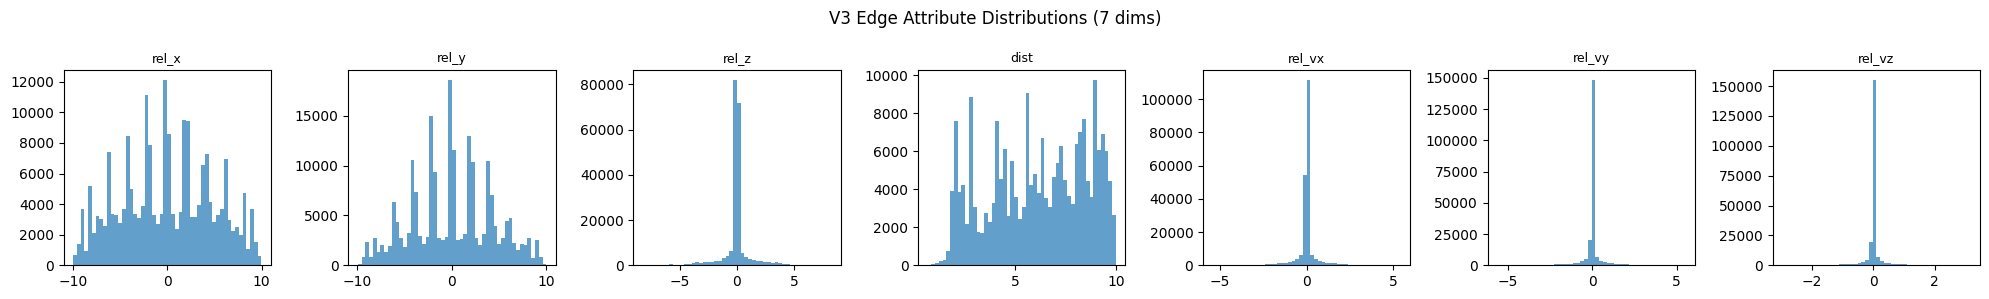

In [5]:
all_e = ds.data.edge_attr
fig, axes = plt.subplots(1, 7, figsize=(20, 3))
names = ['rel_x','rel_y','rel_z','dist','rel_vx','rel_vy','rel_vz']
for i, (ax, n) in enumerate(zip(axes, names)):
    ax.hist(all_e[:, i].numpy(), bins=50, alpha=0.7)
    ax.set_title(n, fontsize=9)
plt.suptitle('V3 Edge Attribute Distributions (7 dims)')
plt.tight_layout()
plt.show()